# **Mineração de Dados Aplicada ao Campeonato Brasileiro de Futebol**

Nesse notebook será realizado a mineração de dados do **Campeonato Brasileiro de Futebol** utilizando técnicas de Machine Learning como `Clusterização` para analisar os padrões dos times brasileiros, bem como inferir características como ofensividade, defensividade e se esses estilos de jogos interferem nas estatísticas de vítorias, empates ou derrotas.

---
**Disciplina: CSI605 - Sistemas de Apoio a Decisão**

Discentes:
- Mateus Henrique dos Santos
- Emanuelle Ferraz Lima



## Importação dos Dados e Bibliotecas

In [5]:
# Bibliotecas Básicas
import pandas as pd
import numpy as np
from google.colab import drive
import datetime
# Bibliotecas de Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
# Sklearn - Métricas, Algoritmos, Pré-Processamento
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [6]:
pd.set_option('display.max_columns', None)

In [7]:
df_stats = pd.read_csv('/content/drive/MyDrive/campeonato-brasileiro-estatisticas-full.csv')
print(df_stats.shape)
df_stats.head()

(17570, 13)


,partida_id,rodada,clube,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios
0,1,1,Vasco,0,0,NaN,0,NaN,0,0,0,0,0
1,1,1,Guarani,0,0,NaN,0,NaN,0,0,0,0,0
2,2,1,Athletico-PR,0,0,NaN,0,NaN,0,0,0,0,0
3,2,1,Gremio,0,0,NaN,0,NaN,0,0,0,0,0
4,3,1,Flamengo,0,0,NaN,0,NaN,0,0,0,0,0


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
df_games = pd.read_csv('/content/drive/MyDrive/campeonato-brasileiro-full.csv')
print(df_games.shape)
df_games.head()

(8785, 16)


,ID,rodada,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado
0,1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ
1,2,1,29/03/2003,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS
2,3,1,30/03/2003,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,Empate,Maracanã,1,1,RJ,PR
3,4,1,30/03/2003,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,Empate,Serra Dourada,2,2,GO,PA
4,5,1,30/03/2003,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,Empate,Beira Rio,1,1,RS,SP


In [10]:
print('**DataFrame de Estatísticas de Jogos**')
print(df_stats.info())
print('-----------------------------------------------')
print('**DataFrame de Jogos Completo**')
print(df_games.info())

**DataFrame de Estatísticas de Jogos**
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17570 entries, 0 to 17569
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   partida_id       17570 non-null  int64 
 1   rodada           17570 non-null  int64 
 2   clube            17570 non-null  object
 3   chutes           17570 non-null  int64 
 4   chutes_no_alvo   17570 non-null  int64 
 5   posse_de_bola    6820 non-null   object
 6   passes           17570 non-null  int64 
 7   precisao_passes  4512 non-null   object
 8   faltas           17570 non-null  int64 
 9   cartao_amarelo   17570 non-null  int64 
 10  cartao_vermelho  17570 non-null  int64 
 11  impedimentos     17570 non-null  int64 
 12  escanteios       17570 non-null  int64 
dtypes: int64(10), object(3)
memory usage: 1.7+ MB
None
-----------------------------------------------
**DataFrame de Jogos Completo**
<class 'pandas.core.frame.DataFrame'>
Ran

## Análise, Filtro e Transformação dos Dados

Observando os tipos dos dados, percebe-se que alguns dados precisam de **transformação**. Por exemplo, a feature de data está como *object* quando deveria ser *datetime*. A transformação dessa coluna será importante para identificar os períodos em que temos o maior número de dados preenchidos, uma vez que algumas features consideradas importantes podem ter muitos **dados nulos**.
Ademais, colunas como posse de bola, precisão dos passes também estão como *object* quando deveriam ser numéricas.

In [11]:
# Transformação dos dados que são data, mas estão como 'object' em 'datetime'
df_games['data'] = pd.to_datetime(df_games['data'], dayfirst=True)
df_games['ano'] = df_games['data'].dt.year

In [12]:
df_stats['posse_de_bola'] = (df_stats['posse_de_bola'].str.replace('%', '', regex=False).str.strip())

In [13]:
df_stats['posse_de_bola'] = pd.to_numeric(df_stats['posse_de_bola'], errors='coerce')

Para identificação do exposto acima, e para melhorar o leque de possibilidades de features que poderão ser usadas para o **agrupamento**, iremos unir os DataFrames.

In [14]:
df_games = df_games.rename(columns={'ID': 'partida_id'})

In [15]:
df_full = df_stats.merge(df_games[['partida_id', 'data', 'ano', 'mandante', 'visitante', 'vencedor', 'mandante_Placar', 'visitante_Placar']], on='partida_id', how='left')
print(df_full.shape)
df_full.head()

(17570, 20)


,partida_id,rodada,clube,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios,data,ano,mandante,visitante,vencedor,mandante_Placar,visitante_Placar
0,1,1,Vasco,0,0,NaN,0,NaN,0,0,0,0,0,2003-03-29,2003,Guarani,Vasco,Guarani,4,2
1,1,1,Guarani,0,0,NaN,0,NaN,0,0,0,0,0,2003-03-29,2003,Guarani,Vasco,Guarani,4,2
2,2,1,Athletico-PR,0,0,NaN,0,NaN,0,0,0,0,0,2003-03-29,2003,Athletico-PR,Gremio,Athletico-PR,2,0
3,2,1,Gremio,0,0,NaN,0,NaN,0,0,0,0,0,2003-03-29,2003,Athletico-PR,Gremio,Athletico-PR,2,0
4,3,1,Flamengo,0,0,NaN,0,NaN,0,0,0,0,0,2003-03-30,2003,Flamengo,Coritiba,Empate,1,1


Abaixo criaremos as features de `gols` por clube usando os dados de *mandante_Placar* e *visitante_Placar*, e `eficiencia nos chutes` usando a feature nova de gols e os *chutes/chutes* no alvo dos clubes.

In [16]:
df_full['gols'] = np.where(
    df_full['clube'] == df_full['mandante'],
    df_full['mandante_Placar'],
    df_full['visitante_Placar']
)
df_full.head()

,partida_id,rodada,clube,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios,data,ano,mandante,visitante,vencedor,mandante_Placar,visitante_Placar,gols
0,1,1,Vasco,0,0,NaN,0,NaN,0,0,0,0,0,2003-03-29,2003,Guarani,Vasco,Guarani,4,2,2
1,1,1,Guarani,0,0,NaN,0,NaN,0,0,0,0,0,2003-03-29,2003,Guarani,Vasco,Guarani,4,2,4
2,2,1,Athletico-PR,0,0,NaN,0,NaN,0,0,0,0,0,2003-03-29,2003,Athletico-PR,Gremio,Athletico-PR,2,0,2
3,2,1,Gremio,0,0,NaN,0,NaN,0,0,0,0,0,2003-03-29,2003,Athletico-PR,Gremio,Athletico-PR,2,0,0
4,3,1,Flamengo,0,0,NaN,0,NaN,0,0,0,0,0,2003-03-30,2003,Flamengo,Coritiba,Empate,1,1,1


In [17]:
# Correção de inconsistências, obrigatoriamente tem que ser: chutes_no_alvo >= gols
df_full.loc[
    (df_full['gols'] > 0) & (df_full['chutes_no_alvo'] == 0),
    'chutes_no_alvo'
] = df_full['gols']

df_full.loc[
    df_full['gols'] > df_full['chutes'],
    'chutes'
] = df_full['gols']

In [18]:
df_full['eficiencia_chute'] = np.where(df_full['chutes'] > 0, df_full['gols'] / df_full['chutes'], 0)
df_full['eficiencia_chute_alvo'] = np.where(df_full['chutes_no_alvo'] > 0, df_full['gols'] / df_full['chutes_no_alvo'], 0)
df_full.head()

,partida_id,rodada,clube,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios,data,ano,mandante,visitante,vencedor,mandante_Placar,visitante_Placar,gols,eficiencia_chute,eficiencia_chute_alvo
0,1,1,Vasco,2,2,NaN,0,NaN,0,0,0,0,0,2003-03-29,2003,Guarani,Vasco,Guarani,4,2,2,1.0,1.0
1,1,1,Guarani,4,4,NaN,0,NaN,0,0,0,0,0,2003-03-29,2003,Guarani,Vasco,Guarani,4,2,4,1.0,1.0
2,2,1,Athletico-PR,2,2,NaN,0,NaN,0,0,0,0,0,2003-03-29,2003,Athletico-PR,Gremio,Athletico-PR,2,0,2,1.0,1.0
3,2,1,Gremio,0,0,NaN,0,NaN,0,0,0,0,0,2003-03-29,2003,Athletico-PR,Gremio,Athletico-PR,2,0,0,0.0,0.0
4,3,1,Flamengo,1,1,NaN,0,NaN,0,0,0,0,0,2003-03-30,2003,Flamengo,Coritiba,Empate,1,1,1,1.0,1.0


### Valores Nulos

In [19]:
df_full.isna().sum()

,0
partida_id,0
rodada,0
clube,0
chutes,0
chutes_no_alvo,0
posse_de_bola,10750
passes,0
precisao_passes,13058
faltas,0
cartao_amarelo,0


In [20]:
# Verificando a completude dos dados a partir de uma data
df_full.groupby('ano')['posse_de_bola'].apply(lambda x: x.notnull().mean())

,posse_de_bola
ano,
2003,0.000000
2004,0.000000
2005,0.000000
2006,0.000000
2007,0.000000
2008,0.000000
2009,0.000000
2010,0.000000
2011,0.000000


In [21]:
df_full.groupby('ano')['chutes'].mean()

,chutes
ano,
2003,1.442029
2004,1.389493
2005,1.570346
2006,1.355263
2007,1.377632
2008,1.361842
2009,1.439474
2010,1.286842
2011,1.338158


A partir da análise da completude da variável *posse de bola*, observou-se que os dados apresentam preenchimento consistente apenas a partir de **2015**.

Ademais, também foi observado que até 2014 variáveis como *chutes, chutes no alvo, faltas*, apesar de não terem valores nulos foram preenchidos com **valores 0**, indicando ausência de registro estatístico.

Dessa forma, o período analisado no estudo compreende as temporadas de **2015 a 2023**, garantindo maior qualidade e consistência estatística.

### Filtragem da Base

In [22]:
df_full = df_full[(df_full['ano'] >= 2015) & (df_full['ano'] <= 2023)]
print(df_full.shape)
df_full.head()

(6838, 23)


,partida_id,rodada,clube,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios,data,ano,mandante,visitante,vencedor,mandante_Placar,visitante_Placar,gols,eficiencia_chute,eficiencia_chute_alvo
9972,4987,1,Coritiba,16,1,55.0,388,NaN,21,2,0,0,5,2015-05-09,2015,Chapecoense,Coritiba,Chapecoense,2,1,1,0.062500,1.0
9973,4987,1,Chapecoense,13,2,45.0,326,NaN,20,2,0,3,3,2015-05-09,2015,Chapecoense,Coritiba,Chapecoense,2,1,2,0.153846,1.0
9974,4988,1,Atletico-MG,10,2,50.0,426,NaN,14,4,0,4,2,2015-05-09,2015,Palmeiras,Atletico-MG,Empate,2,2,2,0.200000,1.0
9975,4988,1,Palmeiras,17,2,50.0,406,NaN,20,2,0,2,11,2015-05-09,2015,Palmeiras,Atletico-MG,Empate,2,2,2,0.117647,1.0
9976,4989,1,Joinville,3,0,26.0,250,NaN,14,0,1,1,3,2015-05-09,2015,Fluminense,Joinville,Fluminense,1,0,0,0.000000,0.0


In [23]:
df_full.isna().sum()

,0
partida_id,0
rodada,0
clube,0
chutes,0
chutes_no_alvo,0
posse_de_bola,50
passes,0
precisao_passes,2326
faltas,0
cartao_amarelo,0


In [24]:
# Inputando com a mediana os valores nulos de posse de bola e eficiencia_chute
df_full['posse_de_bola'].fillna(df_full['posse_de_bola'].median(), inplace=True)
df_full['eficiencia_chute'].fillna(0, inplace=True)

/tmp/ipykernel_172/161024962.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_full['posse_de_bola'].fillna(df_full['posse_de_bola'].median(), inplace=True)
/tmp/ipykernel_172/161024962.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

O objetivo é identificar o **estilo/perfil** de jogo de cada clube, sobretudo os comportamentos **ofensivos** e **defensivos**. Ademais, será possível identificar também o comportamento estatístico.

Pensando nisso, estaremos selecionando as variáveis cujo as características representam:
- volume ofensivo/defensivo
- eficiência
- construção
- comportamento disciplinar

In [25]:
# Selecionando as features interessantes para a clusterização
features = [
    'posse_de_bola',
    'passes',
    'chutes',
    'chutes_no_alvo',
    'eficiencia_chute',
    'escanteios',
    'faltas',
    'cartao_amarelo'
]

## Agrupamento (Clusterização)

Para essa etapa de clusterização, utilizaremos o algoritmo **K-Means**. Antes da aplicação desse algoritmo, faremos a normalização e definicação da quantidade de *clusters*.

In [26]:
df_kmeans = df_full[features]
print(df_kmeans.shape)
df_kmeans.head()

(6838, 8)


,posse_de_bola,passes,chutes,chutes_no_alvo,eficiencia_chute,escanteios,faltas,cartao_amarelo
9972,55.0,388,16,1,0.062500,5,21,2
9973,45.0,326,13,2,0.153846,3,20,2
9974,50.0,426,10,2,0.200000,2,14,4
9975,50.0,406,17,2,0.117647,11,20,2
9976,26.0,250,3,0,0.000000,3,14,0


In [27]:
# Estatística Descritiva
df_kmeans.describe()

,posse_de_bola,passes,chutes,chutes_no_alvo,eficiencia_chute,escanteios,faltas,cartao_amarelo
count,6838.000000,6838.000000,6838.000000,6838.000000,6838.000000,6838.000000,6838.000000,6838.000000
mean,50.000000,419.066832,12.816028,3.602369,0.103392,5.200936,14.844838,2.301843
std,10.604323,105.892491,5.103013,2.481343,0.116481,3.006597,4.632215,1.451623
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,348.000000,9.000000,2.000000,0.000000,3.000000,12.000000,1.000000
50%,50.000000,416.000000,12.000000,3.000000,0.083333,5.000000,15.000000,2.000000
75%,58.000000,487.000000,16.000000,5.000000,0.153846,7.000000,18.000000,3.000000
max,80.000000,848.000000,37.000000,18.000000,1.000000,23.000000,34.000000,10.000000


In [28]:
# Normalização dos dados
scaler = StandardScaler()
df_kmeans = scaler.fit_transform(df_kmeans)

### Número Ideal de Clusters

#### Método Cotovelo

In [29]:
# Elbow
inercia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_kmeans)
    inercia.append(kmeans.inertia_)

# Criando um DataFrame com a quantidade de clusters e WCSS
resultWCSS = pd.DataFrame({'Number of Clusters': K_range, 'WCSS': inercia})

# Exibindo o DataFrame
print(resultWCSS.to_string(index=False))

 Number of Clusters         WCSS
                  2 42784.934420
                  3 38520.951235
                  4 35290.343490
                  5 32627.058448
                  6 30709.900233
                  7 28972.337191
                  8 27666.220959
                  9 26541.635381
                 10 25587.216425


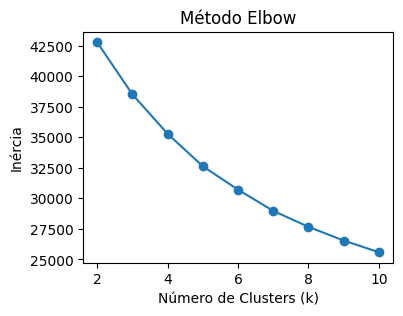

In [30]:
# Elbow graficamente
plt.figure(figsize=(4,3))
plt.plot(K_range, inercia, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método Elbow')
plt.show()

#### Método Silhouette

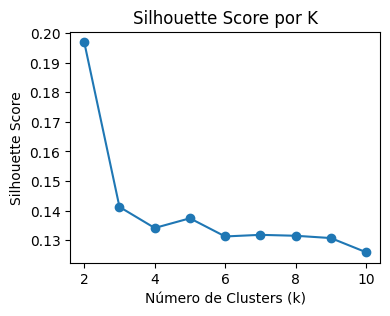

In [31]:
# Silhouette
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_kmeans)
    score = silhouette_score(df_kmeans, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(4,3))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por K')
plt.show()

Analisando os resultados, o método Silhouette indicou maior separação para **k=2** (score ≈ 0.20), por sua vez o método Elbow teve maior ganho marginal até **k=3**, seguido de estabilização.
Desse modo, optou-se por `k=2` por apresentar melhor coesão e maior interpretabilidade

### K-Means Final

In [32]:
nClusters = 2
kmeans = KMeans(n_clusters=nClusters, init='k-means++', n_init=10, random_state=42)
clusters = kmeans.fit_predict(df_kmeans)


# Converte clusters para uma Series do pandas e conta a quantidade de linhas em cada cluster
clusterCounts = pd.Series(clusters).value_counts()

# Imprime o resultado
print(clusterCounts)

0    3768
1    3070
Name: count, dtype: int64


In [33]:
# Aplicando diretamente na base de dados
df_clustered = df_full.copy()
df_clustered['cluster'] = clusters

df_clustered.head()

,partida_id,rodada,clube,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios,data,ano,mandante,visitante,vencedor,mandante_Placar,visitante_Placar,gols,eficiencia_chute,eficiencia_chute_alvo,cluster
9972,4987,1,Coritiba,16,1,55.0,388,NaN,21,2,0,0,5,2015-05-09,2015,Chapecoense,Coritiba,Chapecoense,2,1,1,0.062500,1.0,0
9973,4987,1,Chapecoense,13,2,45.0,326,NaN,20,2,0,3,3,2015-05-09,2015,Chapecoense,Coritiba,Chapecoense,2,1,2,0.153846,1.0,0
9974,4988,1,Atletico-MG,10,2,50.0,426,NaN,14,4,0,4,2,2015-05-09,2015,Palmeiras,Atletico-MG,Empate,2,2,2,0.200000,1.0,0
9975,4988,1,Palmeiras,17,2,50.0,406,NaN,20,2,0,2,11,2015-05-09,2015,Palmeiras,Atletico-MG,Empate,2,2,2,0.117647,1.0,1
9976,4989,1,Joinville,3,0,26.0,250,NaN,14,0,1,1,3,2015-05-09,2015,Fluminense,Joinville,Fluminense,1,0,0,0.000000,0.0,0


In [34]:
# Confirmando a distribuição de clusters
df_clustered['cluster'].value_counts()

,count
cluster,
0,3768
1,3070


In [35]:
# Analisando os valores médios dos atributos para cada cluster
df_clustered.groupby('cluster')[features].mean()

,posse_de_bola,passes,chutes,chutes_no_alvo,eficiencia_chute,escanteios,faltas,cartao_amarelo
cluster,,,,,,,,
0,43.308917,357.360403,10.175955,2.825372,0.124041,3.783439,15.737792,2.534501
1,58.212378,494.802932,16.056352,4.556026,0.078048,6.940717,13.748860,2.016287


#### Avaliando Silhouette

In [36]:
# Análise de Score
sil_score = silhouette_score(df_kmeans, clusters)
print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.1970


In [37]:
sample_silhouette_values = silhouette_samples(df_kmeans, clusters)

# Criando um DataFrame com os valores de Silhouette e os rótulos de cluster
resultSilhouetteSamples = pd.DataFrame({
    'Silhouette Value': sample_silhouette_values,
    'Cluster Label': clusters
})

# Exibindo o DataFrame criado
resultSilhouetteSamples.head(10)

,Silhouette Value,Cluster Label
0,0.058925,0
1,0.310839,0
2,0.241927,0
3,0.100862,1
4,0.300072,0
5,0.296236,1
6,0.130660,1
7,0.240144,0
8,0.249083,0
9,0.073418,0


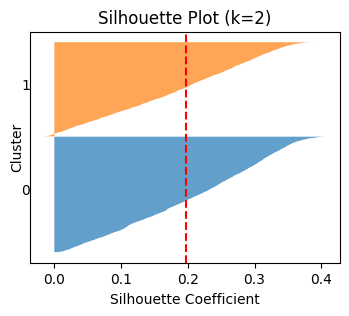

In [38]:
nClusters = 2
fig, ax = plt.subplots(figsize=(4,3))

y_lower = 10

for i in range(nClusters):
    cluster_vals = sample_silhouette_values[clusters == i]
    cluster_vals.sort()

    size_cluster_i = cluster_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_vals,
        alpha=0.7
    )

    ax.text(-0.05, y_lower + size_cluster_i / 2, f"{i}")

    y_lower = y_upper + 10

ax.set_title("Silhouette Plot (k=2)")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")

# Linha média
ax.axvline(x=sil_score, linestyle="--", color="red")

ax.set_yticks([])

plt.show()

In [39]:
for k in range(2, 7):
    kmeans_test = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )

    labels_test = kmeans_test.fit_predict(df_kmeans)
    score = silhouette_score(df_kmeans, labels_test)

    print(f"k = {k} | Silhouette Score = {score:.4f}")


k = 2 | Silhouette Score = 0.1970
k = 3 | Silhouette Score = 0.1412
k = 4 | Silhouette Score = 0.1341
k = 5 | Silhouette Score = 0.1374
k = 6 | Silhouette Score = 0.1313


Embora o coeficiente de Silhouette indique uma separação moderada entre os grupos (0,197), valores superiores não foram obtidos para k maiores, indicando que a **divisão em dois clusters representa a melhor estrutura** possível dentro do conjunto de dados analisado.

### Análise Gráfica dos Clusters

In [40]:
# Realizando PCA para avaliar graficamente
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df_kmeans)

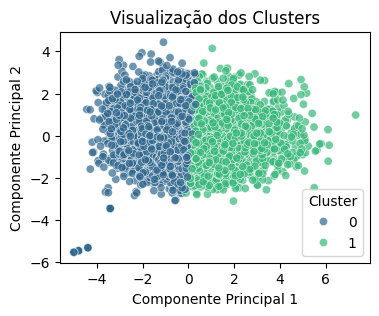

In [41]:
plt.figure(figsize=(4,3))

df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": clusters
})

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="viridis",
    alpha=0.7
)

plt.title("Visualização dos Clusters")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")

plt.show()

O gráfico mostra que o algoritmo conseguiu identificar **dois padrões distintos de jogos**.
A separação é mais evidente na primeira componente, indicando que o **volume ofensivo** foi o principal fator de diferenciação entre os grupos.

In [42]:
df_pca_test = df_full[features]

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df_pca_test.columns
)

print(loadings.sort_values(by='PC1', ascending=False))
print("Variância Explicada:")
print(pca.explained_variance_ratio_)

                       PC1       PC2
posse_de_bola     0.487013 -0.070443
passes            0.474110 -0.089062
chutes            0.464102  0.174403
escanteios        0.415574  0.171529
chutes_no_alvo    0.281081  0.090413
cartao_amarelo   -0.116399  0.641321
faltas           -0.117731  0.667387
eficiencia_chute -0.208637 -0.249789
Variância Explicada:
[0.34353027 0.16939575]


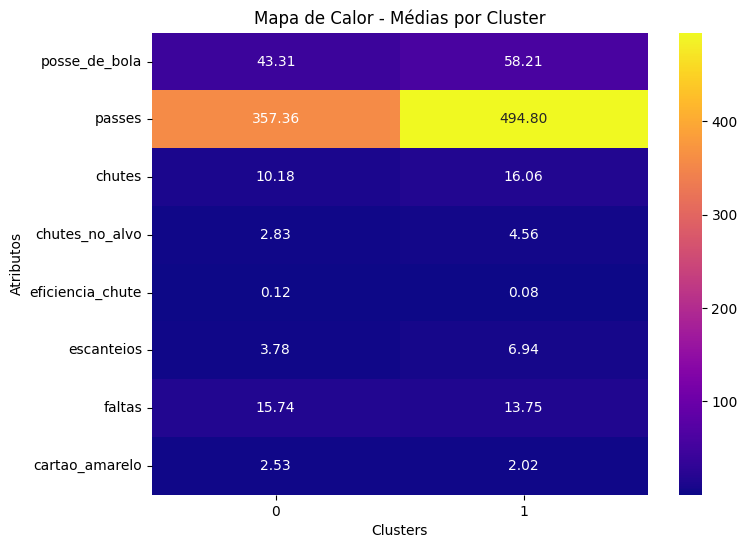

In [43]:
# Média real por cluster (base original)
dfClusterMeans = df_clustered.groupby("cluster")[
    [
        "posse_de_bola",
        "passes",
        "chutes",
        "chutes_no_alvo",
        "eficiencia_chute",
        "escanteios",
        "faltas",
        "cartao_amarelo"
    ]
].mean()

# Transpor para atributos nas linhas
dfHeatMap = dfClusterMeans.transpose()

plt.figure(figsize=(8,6))

sns.heatmap(
    dfHeatMap,
    annot=True,
    cmap="plasma",
    fmt=".2f",
    linewidths=0
)

plt.title("Mapa de Calor - Médias por Cluster")
plt.xlabel("Clusters")
plt.ylabel("Atributos")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.show()


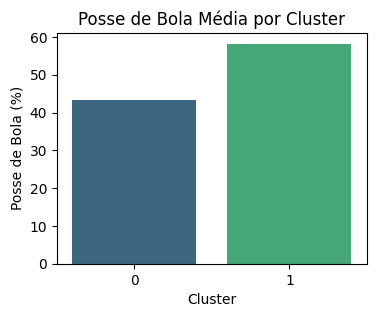

In [44]:
# Posse de Bola Média por Cluster

dfClusterMeans = df_clustered.groupby("cluster")["posse_de_bola"].mean()
plt.figure(figsize=(4,3))

sns.barplot(
    x=dfClusterMeans.index,
    y=dfClusterMeans.values,
    hue=dfClusterMeans.index,
    palette="viridis",
    legend=False
)

plt.title("Posse de Bola Média por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Posse de Bola (%)")

plt.show()


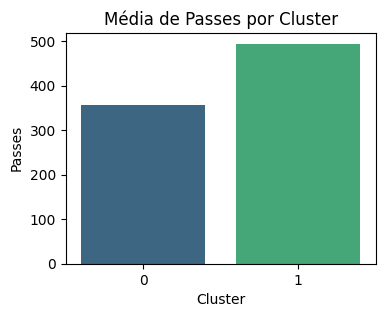

In [45]:
# Média de Passes por Cluster

dfClusterMeans = df_clustered.groupby("cluster")["passes"].mean()
plt.figure(figsize=(4,3))

sns.barplot(
    x=dfClusterMeans.index,
    y=dfClusterMeans.values,
    hue=dfClusterMeans.index,
    palette="viridis",
    legend=False
)

plt.title("Média de Passes por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Passes")

plt.show()


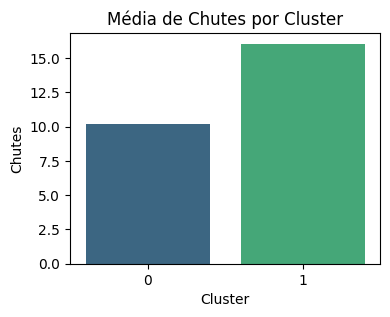

In [46]:
# Média de Chutes por Cluster

dfClusterMeans = df_clustered.groupby("cluster")["chutes"].mean()
plt.figure(figsize=(4,3))

sns.barplot(
    x=dfClusterMeans.index,
    y=dfClusterMeans.values,
    hue=dfClusterMeans.index,
    palette="viridis",
    legend=False
)

plt.title("Média de Chutes por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Chutes")

plt.show()


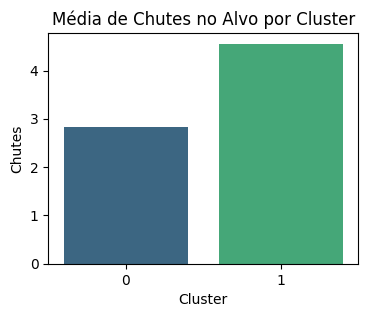

In [47]:
# Média de Chutes no Alvo por Cluster

dfClusterMeans = df_clustered.groupby("cluster")["chutes_no_alvo"].mean()
plt.figure(figsize=(4,3))

sns.barplot(
    x=dfClusterMeans.index,
    y=dfClusterMeans.values,
    hue=dfClusterMeans.index,
    palette="viridis",
    legend=False
)

plt.title("Média de Chutes no Alvo por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Chutes")

plt.show()


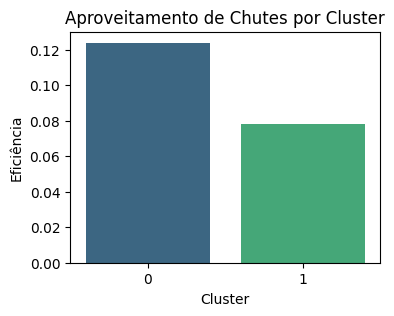

In [48]:
# Eficiência de Chutes por Cluster

dfClusterMeans = df_clustered.groupby("cluster")["eficiencia_chute"].mean()
plt.figure(figsize=(4,3))

sns.barplot(
    x=dfClusterMeans.index,
    y=dfClusterMeans.values,
    hue=dfClusterMeans.index,
    palette="viridis",
    legend=False
)

plt.title("Aproveitamento de Chutes por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Eficiência")

plt.show()


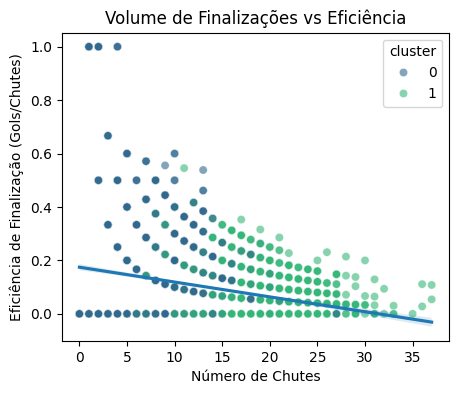

In [49]:
# Times ofensivos são eficientes ou só chutam muito?
plt.figure(figsize=(5,4))

sns.scatterplot(
    data=df_clustered,
    x='chutes',
    y='eficiencia_chute',
    hue='cluster',
    alpha=0.6,
    palette='viridis'
)

sns.regplot(
    data=df_clustered,
    x='chutes',
    y='eficiencia_chute',
    scatter=False,
)

plt.title("Volume de Finalizações vs Eficiência")
plt.xlabel("Número de Chutes")
plt.ylabel("Eficiência de Finalização (Gols/Chutes)")

plt.show()

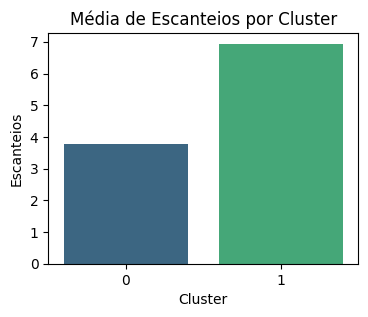

In [50]:
# Média de Escanteios por Cluster

dfClusterMeans = df_clustered.groupby("cluster")["escanteios"].mean()
plt.figure(figsize=(4,3))

sns.barplot(
    x=dfClusterMeans.index,
    y=dfClusterMeans.values,
    hue=dfClusterMeans.index,
    palette="viridis",
    legend=False
)

plt.title("Média de Escanteios por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Escanteios")

plt.show()


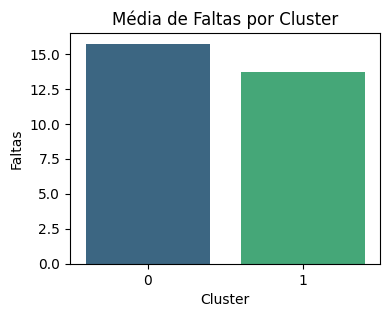

In [51]:
# Média de Faltas por Cluster

dfClusterMeans = df_clustered.groupby("cluster")["faltas"].mean()
plt.figure(figsize=(4,3))

sns.barplot(
    x=dfClusterMeans.index,
    y=dfClusterMeans.values,
    hue=dfClusterMeans.index,
    palette="viridis",
    legend=False
)

plt.title("Média de Faltas por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Faltas")

plt.show()


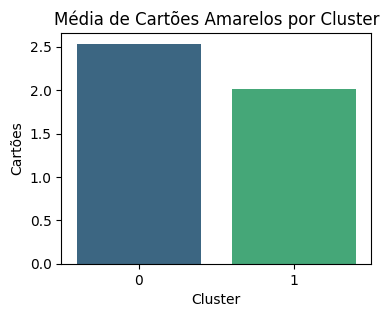

In [52]:
# Média de Cartões Amarelos por Cluster

dfClusterMeans = df_clustered.groupby("cluster")["cartao_amarelo"].mean()
plt.figure(figsize=(4,3))

sns.barplot(
    x=dfClusterMeans.index,
    y=dfClusterMeans.values,
    hue=dfClusterMeans.index,
    palette="viridis",
    legend=False
)

plt.title("Média de Cartões Amarelos por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Cartões")

plt.show()


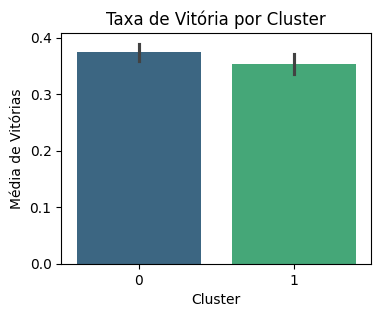

In [53]:
df_winner_rate = df_clustered.copy()
df_winner_rate['vitoria'] = (df_clustered['clube'] == df_clustered['vencedor']).astype(int)
df_winner_rate['empate'] = (df_clustered['vencedor'] == 'Empate').astype(int)

plt.figure(figsize=(4,3))
# Calculando a média de vitórias por cluster
sns.barplot(data=df_winner_rate, x='cluster', y='vitoria', hue='cluster', palette='viridis', legend=False)

plt.title("Taxa de Vitória por Cluster")
plt.ylabel("Média de Vitórias")
plt.xlabel("Cluster")
plt.show()

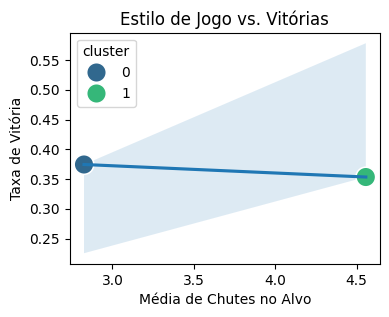

In [54]:
# Time mais ofensivo vence mais?
df_ofensivo = df_winner_rate.groupby('cluster')[['chutes_no_alvo', 'vitoria']].mean().reset_index()

plt.figure(figsize=(4,3))
sns.regplot(data=df_ofensivo, x='chutes_no_alvo', y='vitoria', scatter_kws={'s':100})
sns.scatterplot(data=df_ofensivo, x='chutes_no_alvo', y='vitoria', hue='cluster', s=200, palette='viridis')

plt.title("Estilo de Jogo vs. Vitórias")
plt.xlabel("Média de Chutes no Alvo")
plt.ylabel("Taxa de Vitória")
plt.show()

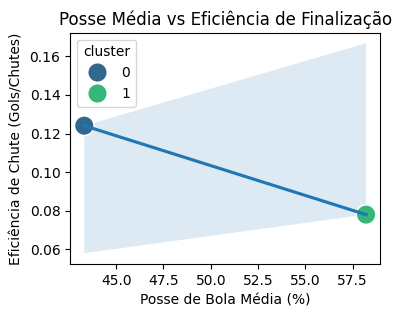

In [55]:
# Posse mais alta indica mais eficiência?
df_eficiencia = df_clustered.groupby('cluster')[['posse_de_bola', 'eficiencia_chute']].mean().reset_index()

plt.figure(figsize=(4,3))
sns.regplot(data=df_eficiencia, x='posse_de_bola', y='eficiencia_chute', scatter_kws={'s':100})
sns.scatterplot(data=df_eficiencia, x='posse_de_bola', y='eficiencia_chute', hue='cluster', s=200, palette='viridis')

plt.title("Posse Média vs Eficiência de Finalização")
plt.ylabel("Eficiência de Chute (Gols/Chutes)")
plt.xlabel("Posse de Bola Média (%)")
plt.show()

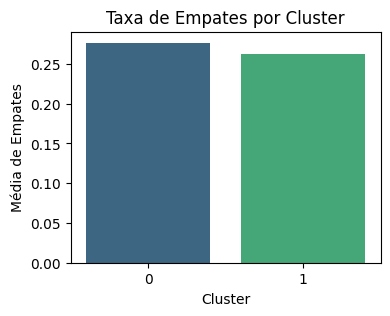

In [56]:
df_defensivo = df_winner_rate.copy()
df_defensivo = df_defensivo.groupby('cluster')[['faltas', 'empate']].mean().reset_index()

plt.figure(figsize=(4,3))
sns.barplot(data=df_defensivo, x='cluster', y='empate', hue='cluster', palette='viridis', legend=False)

plt.title("Taxa de Empates por Cluster")
plt.ylabel("Média de Empates")
plt.xlabel("Cluster")
plt.show()

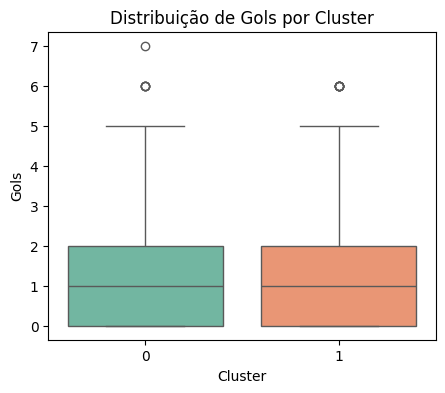

In [57]:
plt.figure(figsize=(5,4))
sns.boxplot(data=df_winner_rate, x='cluster', y='gols', hue='cluster', palette='Set2', legend=False)

plt.title("Distribuição de Gols por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Gols")
plt.show()


In [58]:
df_clustered.groupby('cluster')['gols'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,3768.0,1.147293,1.029851,0.0,0.0,1.0,2.0,7.0
1,3070.0,1.221173,1.168561,0.0,0.0,1.0,2.0,6.0


In [59]:
pd.crosstab(df_clustered['ano'], df_clustered['cluster'], normalize='index')

cluster,0,1
ano,,
2015,0.635526,0.364474
2016,0.646438,0.353562
2017,0.532895,0.467105
2018,0.540789,0.459211
2019,0.548684,0.451316
2020,0.559701,0.440299
2021,0.532520,0.467480
2022,0.485526,0.514474
2023,0.485526,0.514474


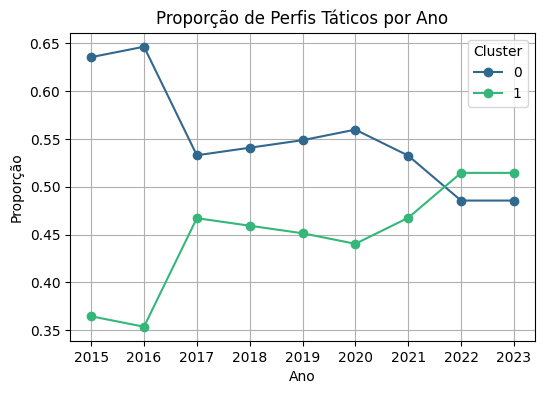

In [60]:
# Proporção ao longo do tempo
df_time = pd.crosstab(
    df_clustered['ano'],
    df_clustered['cluster'],
    normalize='index'
)

cores = sns.color_palette("viridis", n_colors=2)

ax = df_time.plot(
    marker='o',
    figsize=(6,4),
    color=cores
)

plt.title("Proporção de Perfis Táticos por Ano")
plt.ylabel("Proporção")
plt.xlabel("Ano")
plt.legend(title="Cluster")
plt.grid(True)

plt.show()


### Análise de Vitórias Entre Clusters

In [83]:
mandantes = df_clustered[df_clustered['clube'] == df_clustered['mandante']].copy()
visitantes = df_clustered[df_clustered['clube'] == df_clustered['visitante']].copy()

In [85]:
print(mandantes.shape)
mandantes.head()

(3419, 24)


,partida_id,rodada,clube,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios,data,ano,mandante,visitante,vencedor,mandante_Placar,visitante_Placar,gols,eficiencia_chute,eficiencia_chute_alvo,cluster
9973,4987,1,Chapecoense,13,2,45.0,326,NaN,20,2,0,3,3,2015-05-09,2015,Chapecoense,Coritiba,Chapecoense,2,1,2,0.153846,1.000000,0
9975,4988,1,Palmeiras,17,2,50.0,406,NaN,20,2,0,2,11,2015-05-09,2015,Palmeiras,Atletico-MG,Empate,2,2,2,0.117647,1.000000,1
9977,4989,1,Fluminense,26,11,74.0,702,NaN,9,2,0,1,5,2015-05-09,2015,Fluminense,Joinville,Fluminense,1,0,1,0.038462,0.090909,1
9979,4990,1,Gremio,11,3,45.0,401,NaN,17,3,0,2,5,2015-05-10,2015,Gremio,Ponte Preta,Empate,3,3,3,0.272727,1.000000,0
9981,4993,1,Cruzeiro,13,0,56.0,487,NaN,17,3,0,4,2,2015-05-10,2015,Cruzeiro,Corinthians,Corinthians,0,1,0,0.000000,0.000000,0


In [86]:
print(visitantes.shape)
visitantes.head()

(3419, 24)


,partida_id,rodada,clube,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios,data,ano,mandante,visitante,vencedor,mandante_Placar,visitante_Placar,gols,eficiencia_chute,eficiencia_chute_alvo,cluster
9972,4987,1,Coritiba,16,1,55.0,388,NaN,21,2,0,0,5,2015-05-09,2015,Chapecoense,Coritiba,Chapecoense,2,1,1,0.062500,1.0,0
9974,4988,1,Atletico-MG,10,2,50.0,426,NaN,14,4,0,4,2,2015-05-09,2015,Palmeiras,Atletico-MG,Empate,2,2,2,0.200000,1.0,0
9976,4989,1,Joinville,3,0,26.0,250,NaN,14,0,1,1,3,2015-05-09,2015,Fluminense,Joinville,Fluminense,1,0,0,0.000000,0.0,0
9978,4990,1,Ponte Preta,17,3,55.0,473,NaN,21,4,1,0,10,2015-05-10,2015,Gremio,Ponte Preta,Empate,3,3,3,0.176471,1.0,1
9980,4993,1,Corinthians,11,1,44.0,391,NaN,15,1,0,2,4,2015-05-10,2015,Cruzeiro,Corinthians,Corinthians,0,1,1,0.090909,1.0,0


In [87]:
# Juntando na mesma partida
confrontos = mandantes.merge(
    visitantes,
    on='partida_id',
    suffixes=('_mand', '_visit')
)
print(confrontos.shape)
confrontos.head()

(3419, 47)


,partida_id,rodada_mand,clube_mand,chutes_mand,chutes_no_alvo_mand,posse_de_bola_mand,passes_mand,precisao_passes_mand,faltas_mand,cartao_amarelo_mand,cartao_vermelho_mand,impedimentos_mand,escanteios_mand,data_mand,ano_mand,mandante_mand,visitante_mand,vencedor_mand,mandante_Placar_mand,visitante_Placar_mand,gols_mand,eficiencia_chute_mand,eficiencia_chute_alvo_mand,cluster_mand,rodada_visit,clube_visit,chutes_visit,chutes_no_alvo_visit,posse_de_bola_visit,passes_visit,precisao_passes_visit,faltas_visit,cartao_amarelo_visit,cartao_vermelho_visit,impedimentos_visit,escanteios_visit,data_visit,ano_visit,mandante_visit,visitante_visit,vencedor_visit,mandante_Placar_visit,visitante_Placar_visit,gols_visit,eficiencia_chute_visit,eficiencia_chute_alvo_visit,cluster_visit
0,4987,1,Chapecoense,13,2,45.0,326,NaN,20,2,0,3,3,2015-05-09,2015,Chapecoense,Coritiba,Chapecoense,2,1,2,0.153846,1.000000,0,1,Coritiba,16,1,55.0,388,NaN,21,2,0,0,5,2015-05-09,2015,Chapecoense,Coritiba,Chapecoense,2,1,1,0.062500,1.0,0
1,4988,1,Palmeiras,17,2,50.0,406,NaN,20,2,0,2,11,2015-05-09,2015,Palmeiras,Atletico-MG,Empate,2,2,2,0.117647,1.000000,1,1,Atletico-MG,10,2,50.0,426,NaN,14,4,0,4,2,2015-05-09,2015,Palmeiras,Atletico-MG,Empate,2,2,2,0.200000,1.0,0
2,4989,1,Fluminense,26,11,74.0,702,NaN,9,2,0,1,5,2015-05-09,2015,Fluminense,Joinville,Fluminense,1,0,1,0.038462,0.090909,1,1,Joinville,3,0,26.0,250,NaN,14,0,1,1,3,2015-05-09,2015,Fluminense,Joinville,Fluminense,1,0,0,0.000000,0.0,0
3,4990,1,Gremio,11,3,45.0,401,NaN,17,3,0,2,5,2015-05-10,2015,Gremio,Ponte Preta,Empate,3,3,3,0.272727,1.000000,0,1,Ponte Preta,17,3,55.0,473,NaN,21,4,1,0,10,2015-05-10,2015,Gremio,Ponte Preta,Empate,3,3,3,0.176471,1.0,1
4,4993,1,Cruzeiro,13,0,56.0,487,NaN,17,3,0,4,2,2015-05-10,2015,Cruzeiro,Corinthians,Corinthians,0,1,0,0.000000,0.000000,0,1,Corinthians,11,1,44.0,391,NaN,15,1,0,2,4,2015-05-10,2015,Cruzeiro,Corinthians,Corinthians,0,1,1,0.090909,1.0,0


In [88]:
# Criando variável de resultado numérica
def resultado_num(row):
    if row['vencedor_mand'] == row['mandante_mand']:
        return 1
    elif row['vencedor_mand'] == 'Empate':
        return 0
    else:
        return -1

confrontos['resultado'] = confrontos.apply(resultado_num, axis=1)

In [98]:
df_resultados = confrontos.groupby(['cluster_mand','cluster_visit'])['resultado'].value_counts(normalize=True)

In [99]:
df_resultados.head()

cluster_mand  cluster_visit  resultado
0             0               1           0.499168
                              0           0.291181
                             -1           0.209651
              1               1           0.551495
                              0           0.243632
Name: proportion, dtype: float64

In [102]:
plot_df = df_resultados.unstack()
plot_df.head()

resultado                         -1         0         1
cluster_mand cluster_visit                              
0            0              0.209651  0.291181  0.499168
             1              0.204873  0.243632  0.551495
1            0              0.292844  0.283824  0.423331
             1              0.206349  0.222222  0.571429

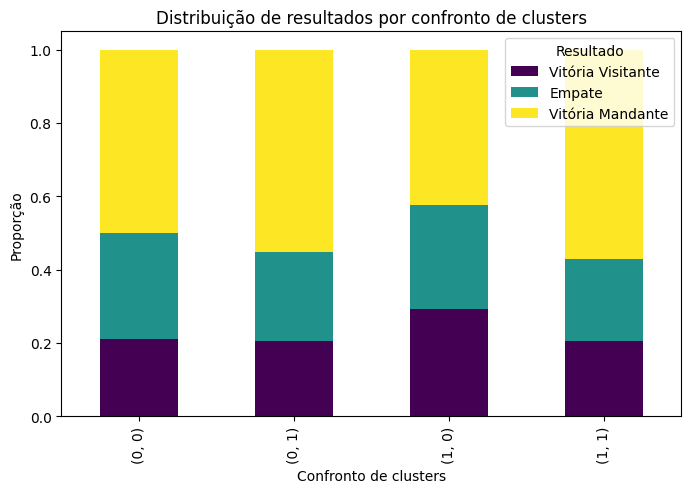

In [104]:
# Plotando resultados
plot_df.columns = [
    'Vitória Visitante',
    'Empate',
    'Vitória Mandante'
]

plot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
    colormap='viridis'
)

plt.ylabel("Proporção")
plt.xlabel("Confronto de clusters")
plt.title("Distribuição de resultados por confronto de clusters")

plt.legend(title="Resultado")
plt.show()

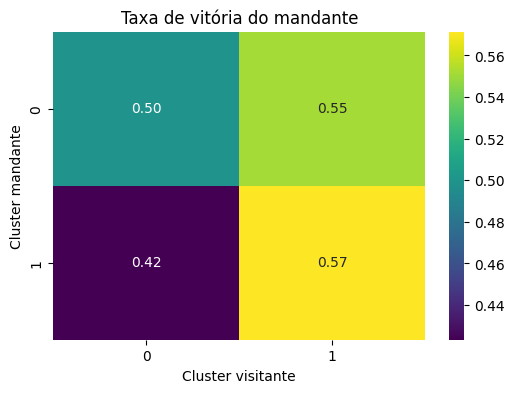

In [106]:
heatmap_data = df_resultados.xs(1, level='resultado').unstack()
plt.figure(figsize=(6,4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Taxa de vitória do mandante")
plt.xlabel("Cluster visitante")
plt.ylabel("Cluster mandante")

plt.show()

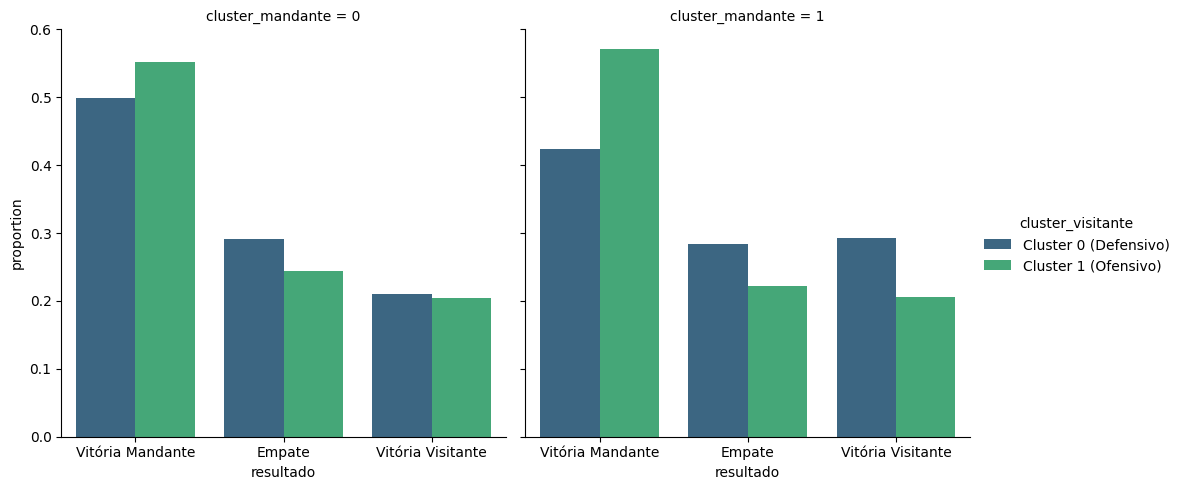

In [114]:
df_plot = df_resultados.reset_index()
df_plot = df_plot.rename(columns={'cluster_mand': 'cluster_mandante', 'cluster_visit': 'cluster_visitante'})
df_plot['resultado'] = df_plot['resultado'].map({
    -1: 'Vitória Visitante',
     0: 'Empate',
     1: 'Vitória Mandante'
})
df_plot['cluster_visitante'] = df_plot['cluster_visitante'].map({
    0: 'Cluster 0 (Defensivo)',
    1: 'Cluster 1 (Ofensivo)'
})

sns.catplot(
    data=df_plot,
    x="resultado",
    y="proportion",
    col="cluster_mandante",
    hue="cluster_visitante",
    kind="bar",
    palette="viridis"
)

In [113]:
df_plot

,cluster_mandante,cluster_visitante,resultado,proportion
0,0,0,Vitória Mandante,0.499168
1,0,0,Empate,0.291181
2,0,0,Vitória Visitante,0.209651
3,0,1,Vitória Mandante,0.551495
4,0,1,Empate,0.243632
5,0,1,Vitória Visitante,0.204873
6,1,0,Vitória Mandante,0.423331
7,1,0,Vitória Visitante,0.292844
8,1,0,Empate,0.283824
9,1,1,Vitória Mandante,0.571429


## EXTRA: Classificação

O objetivo dessa seção é realizar a previsão de qual seria o **resultado** das partidas, mas principalmente, verificar se a clusterização como atributo melhora a previsão.

Para fazer a classificação é preciso inicialmente transformar a base para nível de partida, ou seja, **uma linha por partida**. Com diferenças sobre o mandante e visitante.

### Transformação da Base

In [61]:
# Separação mandante / visitante
df_mandante = df_clustered[df_clustered['clube'] == df_clustered['mandante']]
df_visitante = df_clustered[df_clustered['clube'] == df_clustered['visitante']]

print(df_mandante.shape)
display(df_mandante.head())
print(df_visitante.shape)
display(df_visitante.head())

(3419, 24)


,partida_id,rodada,clube,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios,data,ano,mandante,visitante,vencedor,mandante_Placar,visitante_Placar,gols,eficiencia_chute,eficiencia_chute_alvo,cluster
9973,4987,1,Chapecoense,13,2,45.0,326,NaN,20,2,0,3,3,2015-05-09,2015,Chapecoense,Coritiba,Chapecoense,2,1,2,0.153846,1.000000,0
9975,4988,1,Palmeiras,17,2,50.0,406,NaN,20,2,0,2,11,2015-05-09,2015,Palmeiras,Atletico-MG,Empate,2,2,2,0.117647,1.000000,1
9977,4989,1,Fluminense,26,11,74.0,702,NaN,9,2,0,1,5,2015-05-09,2015,Fluminense,Joinville,Fluminense,1,0,1,0.038462,0.090909,1
9979,4990,1,Gremio,11,3,45.0,401,NaN,17,3,0,2,5,2015-05-10,2015,Gremio,Ponte Preta,Empate,3,3,3,0.272727,1.000000,0
9981,4993,1,Cruzeiro,13,0,56.0,487,NaN,17,3,0,4,2,2015-05-10,2015,Cruzeiro,Corinthians,Corinthians,0,1,0,0.000000,0.000000,0


(3419, 24)


,partida_id,rodada,clube,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios,data,ano,mandante,visitante,vencedor,mandante_Placar,visitante_Placar,gols,eficiencia_chute,eficiencia_chute_alvo,cluster
9972,4987,1,Coritiba,16,1,55.0,388,NaN,21,2,0,0,5,2015-05-09,2015,Chapecoense,Coritiba,Chapecoense,2,1,1,0.062500,1.0,0
9974,4988,1,Atletico-MG,10,2,50.0,426,NaN,14,4,0,4,2,2015-05-09,2015,Palmeiras,Atletico-MG,Empate,2,2,2,0.200000,1.0,0
9976,4989,1,Joinville,3,0,26.0,250,NaN,14,0,1,1,3,2015-05-09,2015,Fluminense,Joinville,Fluminense,1,0,0,0.000000,0.0,0
9978,4990,1,Ponte Preta,17,3,55.0,473,NaN,21,4,1,0,10,2015-05-10,2015,Gremio,Ponte Preta,Empate,3,3,3,0.176471,1.0,1
9980,4993,1,Corinthians,11,1,44.0,391,NaN,15,1,0,2,4,2015-05-10,2015,Cruzeiro,Corinthians,Corinthians,0,1,1,0.090909,1.0,0


In [62]:
df_mandante = df_mandante.add_prefix('home_')
df_visitante = df_visitante.add_prefix('away_')

df_model = df_mandante.merge(
    df_visitante,
    left_on='home_partida_id',
    right_on='away_partida_id'
)

In [63]:
print(df_model.shape)
df_model.head()

(3419, 48)


,home_partida_id,home_rodada,home_clube,home_chutes,home_chutes_no_alvo,home_posse_de_bola,home_passes,home_precisao_passes,home_faltas,home_cartao_amarelo,home_cartao_vermelho,home_impedimentos,home_escanteios,home_data,home_ano,home_mandante,home_visitante,home_vencedor,home_mandante_Placar,home_visitante_Placar,home_gols,home_eficiencia_chute,home_eficiencia_chute_alvo,home_cluster,away_partida_id,away_rodada,away_clube,away_chutes,away_chutes_no_alvo,away_posse_de_bola,away_passes,away_precisao_passes,away_faltas,away_cartao_amarelo,away_cartao_vermelho,away_impedimentos,away_escanteios,away_data,away_ano,away_mandante,away_visitante,away_vencedor,away_mandante_Placar,away_visitante_Placar,away_gols,away_eficiencia_chute,away_eficiencia_chute_alvo,away_cluster
0,4987,1,Chapecoense,13,2,45.0,326,NaN,20,2,0,3,3,2015-05-09,2015,Chapecoense,Coritiba,Chapecoense,2,1,2,0.153846,1.000000,0,4987,1,Coritiba,16,1,55.0,388,NaN,21,2,0,0,5,2015-05-09,2015,Chapecoense,Coritiba,Chapecoense,2,1,1,0.062500,1.0,0
1,4988,1,Palmeiras,17,2,50.0,406,NaN,20,2,0,2,11,2015-05-09,2015,Palmeiras,Atletico-MG,Empate,2,2,2,0.117647,1.000000,1,4988,1,Atletico-MG,10,2,50.0,426,NaN,14,4,0,4,2,2015-05-09,2015,Palmeiras,Atletico-MG,Empate,2,2,2,0.200000,1.0,0
2,4989,1,Fluminense,26,11,74.0,702,NaN,9,2,0,1,5,2015-05-09,2015,Fluminense,Joinville,Fluminense,1,0,1,0.038462,0.090909,1,4989,1,Joinville,3,0,26.0,250,NaN,14,0,1,1,3,2015-05-09,2015,Fluminense,Joinville,Fluminense,1,0,0,0.000000,0.0,0
3,4990,1,Gremio,11,3,45.0,401,NaN,17,3,0,2,5,2015-05-10,2015,Gremio,Ponte Preta,Empate,3,3,3,0.272727,1.000000,0,4990,1,Ponte Preta,17,3,55.0,473,NaN,21,4,1,0,10,2015-05-10,2015,Gremio,Ponte Preta,Empate,3,3,3,0.176471,1.0,1
4,4993,1,Cruzeiro,13,0,56.0,487,NaN,17,3,0,4,2,2015-05-10,2015,Cruzeiro,Corinthians,Corinthians,0,1,0,0.000000,0.000000,0,4993,1,Corinthians,11,1,44.0,391,NaN,15,1,0,2,4,2015-05-10,2015,Cruzeiro,Corinthians,Corinthians,0,1,1,0.090909,1.0,0


In [64]:
df_model['vencedor'] = df_model['home_vencedor']
df_model = df_model.drop(columns=['home_vencedor', 'away_vencedor'])

In [65]:
df_model = df_model.drop(columns=['home_precisao_passes', 'away_precisao_passes'])

In [66]:
print(df_model.shape)
df_model.head()

(3419, 45)


,home_partida_id,home_rodada,home_clube,home_chutes,home_chutes_no_alvo,home_posse_de_bola,home_passes,home_faltas,home_cartao_amarelo,home_cartao_vermelho,home_impedimentos,home_escanteios,home_data,home_ano,home_mandante,home_visitante,home_mandante_Placar,home_visitante_Placar,home_gols,home_eficiencia_chute,home_eficiencia_chute_alvo,home_cluster,away_partida_id,away_rodada,away_clube,away_chutes,away_chutes_no_alvo,away_posse_de_bola,away_passes,away_faltas,away_cartao_amarelo,away_cartao_vermelho,away_impedimentos,away_escanteios,away_data,away_ano,away_mandante,away_visitante,away_mandante_Placar,away_visitante_Placar,away_gols,away_eficiencia_chute,away_eficiencia_chute_alvo,away_cluster,vencedor
0,4987,1,Chapecoense,13,2,45.0,326,20,2,0,3,3,2015-05-09,2015,Chapecoense,Coritiba,2,1,2,0.153846,1.000000,0,4987,1,Coritiba,16,1,55.0,388,21,2,0,0,5,2015-05-09,2015,Chapecoense,Coritiba,2,1,1,0.062500,1.0,0,Chapecoense
1,4988,1,Palmeiras,17,2,50.0,406,20,2,0,2,11,2015-05-09,2015,Palmeiras,Atletico-MG,2,2,2,0.117647,1.000000,1,4988,1,Atletico-MG,10,2,50.0,426,14,4,0,4,2,2015-05-09,2015,Palmeiras,Atletico-MG,2,2,2,0.200000,1.0,0,Empate
2,4989,1,Fluminense,26,11,74.0,702,9,2,0,1,5,2015-05-09,2015,Fluminense,Joinville,1,0,1,0.038462,0.090909,1,4989,1,Joinville,3,0,26.0,250,14,0,1,1,3,2015-05-09,2015,Fluminense,Joinville,1,0,0,0.000000,0.0,0,Fluminense
3,4990,1,Gremio,11,3,45.0,401,17,3,0,2,5,2015-05-10,2015,Gremio,Ponte Preta,3,3,3,0.272727,1.000000,0,4990,1,Ponte Preta,17,3,55.0,473,21,4,1,0,10,2015-05-10,2015,Gremio,Ponte Preta,3,3,3,0.176471,1.0,1,Empate
4,4993,1,Cruzeiro,13,0,56.0,487,17,3,0,4,2,2015-05-10,2015,Cruzeiro,Corinthians,0,1,0,0.000000,0.000000,0,4993,1,Corinthians,11,1,44.0,391,15,1,0,2,4,2015-05-10,2015,Cruzeiro,Corinthians,0,1,1,0.090909,1.0,0,Corinthians


A variável alvo `vencedor` será transformada para uma classe numérica de forma que:
- Empate = 0
- Vitória Mandante = 1
- Vitória Visitante = -1

In [67]:
def definir_target(row):
    if row['vencedor'] == 'Empate':
        return 0
    elif row['vencedor'] == row['home_clube']:
        return 1  # vitória mandante
    else:
        return -1  # vitória visitante

df_model['target'] = df_model.apply(definir_target, axis=1)
print(df_model.shape)
df_model.head()

(3419, 46)


,home_partida_id,home_rodada,home_clube,home_chutes,home_chutes_no_alvo,home_posse_de_bola,home_passes,home_faltas,home_cartao_amarelo,home_cartao_vermelho,home_impedimentos,home_escanteios,home_data,home_ano,home_mandante,home_visitante,home_mandante_Placar,home_visitante_Placar,home_gols,home_eficiencia_chute,home_eficiencia_chute_alvo,home_cluster,away_partida_id,away_rodada,away_clube,away_chutes,away_chutes_no_alvo,away_posse_de_bola,away_passes,away_faltas,away_cartao_amarelo,away_cartao_vermelho,away_impedimentos,away_escanteios,away_data,away_ano,away_mandante,away_visitante,away_mandante_Placar,away_visitante_Placar,away_gols,away_eficiencia_chute,away_eficiencia_chute_alvo,away_cluster,vencedor,target
0,4987,1,Chapecoense,13,2,45.0,326,20,2,0,3,3,2015-05-09,2015,Chapecoense,Coritiba,2,1,2,0.153846,1.000000,0,4987,1,Coritiba,16,1,55.0,388,21,2,0,0,5,2015-05-09,2015,Chapecoense,Coritiba,2,1,1,0.062500,1.0,0,Chapecoense,1
1,4988,1,Palmeiras,17,2,50.0,406,20,2,0,2,11,2015-05-09,2015,Palmeiras,Atletico-MG,2,2,2,0.117647,1.000000,1,4988,1,Atletico-MG,10,2,50.0,426,14,4,0,4,2,2015-05-09,2015,Palmeiras,Atletico-MG,2,2,2,0.200000,1.0,0,Empate,0
2,4989,1,Fluminense,26,11,74.0,702,9,2,0,1,5,2015-05-09,2015,Fluminense,Joinville,1,0,1,0.038462,0.090909,1,4989,1,Joinville,3,0,26.0,250,14,0,1,1,3,2015-05-09,2015,Fluminense,Joinville,1,0,0,0.000000,0.0,0,Fluminense,1
3,4990,1,Gremio,11,3,45.0,401,17,3,0,2,5,2015-05-10,2015,Gremio,Ponte Preta,3,3,3,0.272727,1.000000,0,4990,1,Ponte Preta,17,3,55.0,473,21,4,1,0,10,2015-05-10,2015,Gremio,Ponte Preta,3,3,3,0.176471,1.0,1,Empate,0
4,4993,1,Cruzeiro,13,0,56.0,487,17,3,0,4,2,2015-05-10,2015,Cruzeiro,Corinthians,0,1,0,0.000000,0.000000,0,4993,1,Corinthians,11,1,44.0,391,15,1,0,2,4,2015-05-10,2015,Cruzeiro,Corinthians,0,1,1,0.090909,1.0,0,Corinthians,-1


### Filtro da Base de Dados

Na base existem colunas que não serão necessárias, além de ter colunas redundantes, dado isso estaremos removendo elas e deixando apenas os dados estatísticos e depois mantendo as features de diferença pro modelo.

In [68]:
colunas_remover = [
    'home_partida_id', 'away_partida_id',
    'home_clube', 'away_clube',
    'home_mandante', 'home_visitante',
    'away_mandante', 'away_visitante',
    'vencedor',
    'home_data', 'away_data',
    'home_ano', 'away_ano',
    'home_rodada', 'away_rodada',
    'home_mandante_Placar', 'home_visitante_Placar',
    'away_mandante_Placar', 'away_visitante_Placar',
    'home_gols', 'away_gols',
    'home_eficiencia_chute', 'away_eficiencia_chute',
    'home_eficiencia_chute_alvo', 'away_eficiencia_chute_alvo',

]

df_model = df_model.drop(columns=colunas_remover)


In [69]:
print(df_model.shape)
df_model.head()

(3419, 21)


,home_chutes,home_chutes_no_alvo,home_posse_de_bola,home_passes,home_faltas,home_cartao_amarelo,home_cartao_vermelho,home_impedimentos,home_escanteios,home_cluster,away_chutes,away_chutes_no_alvo,away_posse_de_bola,away_passes,away_faltas,away_cartao_amarelo,away_cartao_vermelho,away_impedimentos,away_escanteios,away_cluster,target
0,13,2,45.0,326,20,2,0,3,3,0,16,1,55.0,388,21,2,0,0,5,0,1
1,17,2,50.0,406,20,2,0,2,11,1,10,2,50.0,426,14,4,0,4,2,0,0
2,26,11,74.0,702,9,2,0,1,5,1,3,0,26.0,250,14,0,1,1,3,0,1
3,11,3,45.0,401,17,3,0,2,5,0,17,3,55.0,473,21,4,1,0,10,1,0
4,13,0,56.0,487,17,3,0,4,2,0,11,1,44.0,391,15,1,0,2,4,0,-1


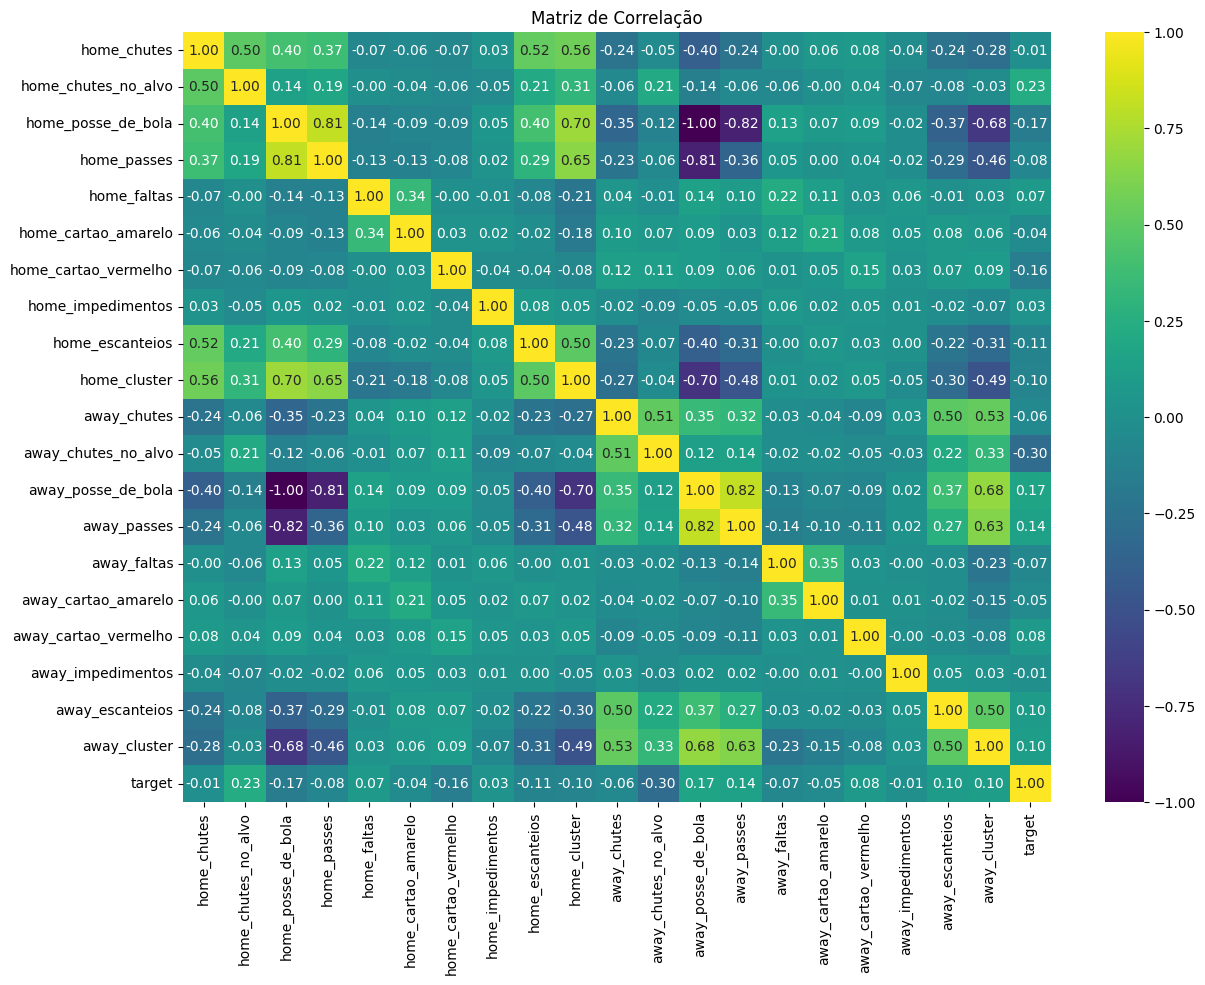

In [70]:
plt.figure(figsize=(14,10))
sns.heatmap(df_model.corr(), cmap='viridis', annot=True, fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

### Modelagem

In [71]:
# Separação dos dados
X = df_model.drop('target', axis=1)
y = df_model['target']

#### Modelo Sem Cluster

In [72]:
X_sem_cluster = X.drop(['home_cluster', 'away_cluster'], axis=1)

In [73]:
X_train_sc, X_test_sc, y_train_sc, y_test_sc = train_test_split(X_sem_cluster, y, test_size=0.2, random_state=42, stratify=y)

In [74]:
# Normalização
scaler_sc = StandardScaler()
X_train_sc = scaler_sc.fit_transform(X_train_sc)
X_test_sc = scaler_sc.transform(X_test_sc)

In [75]:
rf_sc = RandomForestClassifier(random_state=42)
rf_sc.fit(X_train_sc, y_train_sc)

RandomForestClassifier(random_state=42)

In [76]:
# Previsão
y_pred_sc = rf_sc.predict(X_test_sc)

============= MÉTRICAS ===============
Acurácia: 0.6432748538011696
Precisão: 0.6253514173930633
Recall: 0.6432748538011696
F1-Score: 0.6167630456075899
Matriz de Confusão:


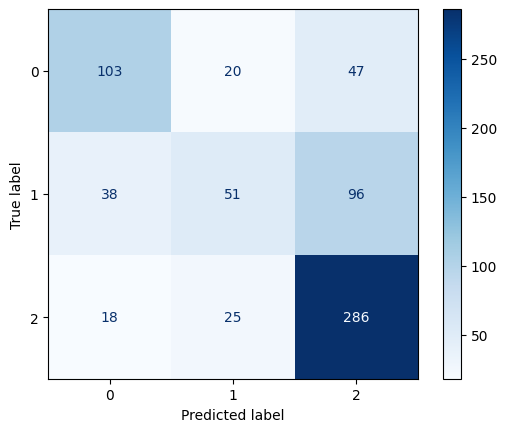

In [77]:
# Métricas
print("============= MÉTRICAS ===============")
print("Acurácia:", accuracy_score(y_test_sc, y_pred_sc))
print("Precisão:", precision_score(y_test_sc, y_pred_sc, average='weighted'))
print("Recall:", recall_score(y_test_sc, y_pred_sc, average='weighted'))
print("F1-Score:", f1_score(y_test_sc, y_pred_sc, average='weighted'))
print("Matriz de Confusão:")
cm = confusion_matrix(y_test_sc, y_pred_sc)
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm)
display_cm.plot(cmap='Blues')
plt.show()



#### Modelo Com Cluster

In [78]:
X_com_cluster = X.copy()
X_train_cc, X_test_cc, y_train_cc, y_test_cc = train_test_split(X_com_cluster, y, test_size=0.2, random_state=42, stratify=y)

In [79]:
# Normalização
scaler_cc = StandardScaler()
X_train_cc = scaler_cc.fit_transform(X_train_cc)
X_test_cc = scaler_cc.transform(X_test_cc)

In [80]:
rf_cc = RandomForestClassifier(random_state=42)
rf_cc.fit(X_train_cc, y_train_cc)

RandomForestClassifier(random_state=42)

In [81]:
# Previsão
y_pred_cc = rf_cc.predict(X_test_cc)

============= MÉTRICAS ===============
Acurácia: 0.6432748538011696
Precisão: 0.6311024253859521
Recall: 0.6432748538011696
F1-Score: 0.612950269080968
Matriz de Confusão:


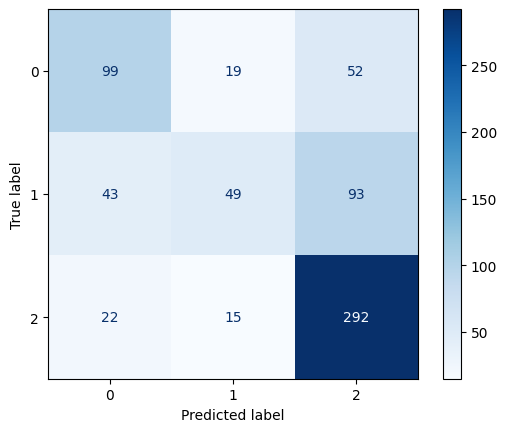

In [82]:
# Métricas
print("============= MÉTRICAS ===============")
print("Acurácia:", accuracy_score(y_test_cc, y_pred_cc))
print("Precisão:", precision_score(y_test_cc, y_pred_cc, average='weighted'))
print("Recall:", recall_score(y_test_cc, y_pred_cc, average='weighted'))
print("F1-Score:", f1_score(y_test_cc, y_pred_cc, average='weighted'))
print("Matriz de Confusão:")
cm = confusion_matrix(y_test_cc, y_pred_cc)
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm)
display_cm.plot(cmap='Blues')
plt.show()

Como podemos observar nos resultados acima comparando o modelo sem cluster e o com cluster como atributo, a inserção deste não contribui significantemente para o modelo, melhora bem pouco a precisão, mantém a acurácia e chega a cair um pouco no F1 score. Dessa forma, com os resultados e a matriz de correlação concluímos que a clusterização realizada na qual apresenta o estilo de jogo do time, **não melhora a previsão de resultados das partidas**.